In [1]:
from scipy.optimize import fsolve
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def solve_for_alpha(u, v, initial_guess=0.0):
    """
    Solves the equation: alpha + 1 - 2(u + v) + v * 2^(-alpha) = 0
    """
    def equation(alpha):
        return alpha + 1 - 2*(u + v) + v * (2.0 ** (-alpha))
    
    # fsolve returns an array, we extract the first element
    alpha_solution = fsolve(equation, initial_guess, xtol=1e-10)[0]
    
    # Verify the solution is close to zero (optional checking)
    tolerance = 1e-6
    if abs(equation(alpha_solution)) > tolerance:
        print("Warning: The solver may not have converged to a true root.")
        
    return alpha_solution

In [7]:
def compute_zns(n, u, v, initial_values = (1, 0)):

    zns = np.zeros(n+1)
    sums = np.zeros(n+1)

    zns[1] = initial_values[0]
    zns[2] = initial_values[1]

    sums[1] = zns[1]
    sums[2] = zns[1] + zns[2]

    for iPlus2 in range(3, n+1):
        i = iPlus2 - 2
        zns[i+2] = (2*u/i)*sums[i] + (v/i)*np.sum([np.max([zns[j], zns[i+1-j]]) for j in range(1, i+1)])

        sums[i+2] = sums[i+1] + zns[i+2]

    return zns

Computed alpha: 0.319037206273529
0.3188693368950827


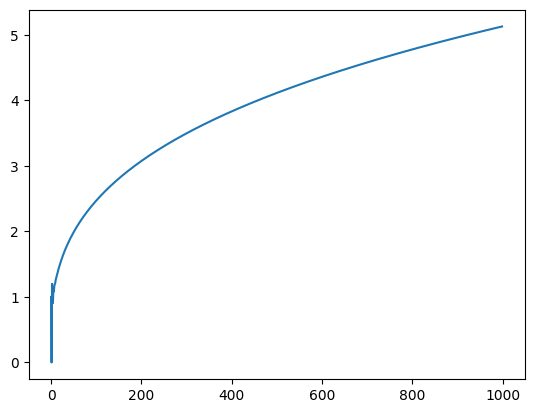

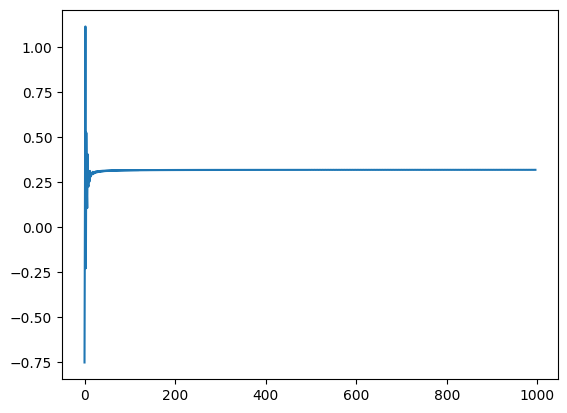

In [10]:
u = 0.3
v = 0.6
n = 1000

alpha = solve_for_alpha(u, v)
print(f"Computed alpha: {alpha}")

zns = compute_zns(n, u, v, [1, 0])
print((n-1)*(zns[n]-zns[n-1])/zns[n-1])

plt.plot(zns[1:], label='zns')
plt.show()

plt.plot([i*(zns[i+1]-zns[i])/zns[i] for i in range(3, n)], label='zns')
plt.show()

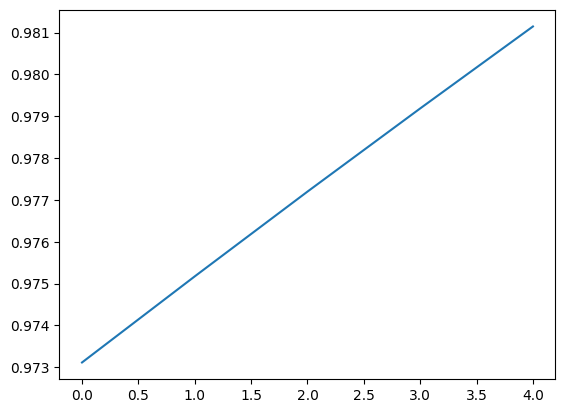

In [46]:
plt.plot(zns[50:55], label='zns[50:55]')

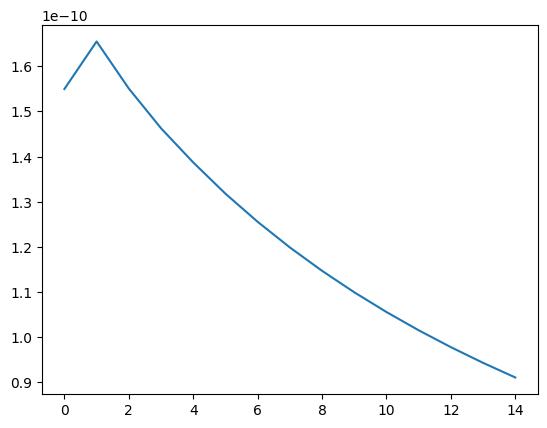

In [308]:
plt.plot([zns[i+1]-zns[i] for i in range(15, 30)], label='$z_{i+1} - z_i$')
plt.show()

In [8]:
zns[-1]

np.float64(0.009129252661632212)

In [ ]:
def compute_yn(n, u, v):
    yns = np.zeros(n+1)
    sums = np.zeros(n+1)

    yns[1] = 1
    yns[2] = 0

    sums[0] = 1
    sums[1] = 1

    for i in range(3, n+1):
        yns[i] = (2*u*sums[i-1] + 2*v*(sums[i-1] - sums[(i-1)//2-1])) / i
        sums[i] = sums[i-1] + yns[i]

    return yns 

Computed alpha: 0.5213031132052071


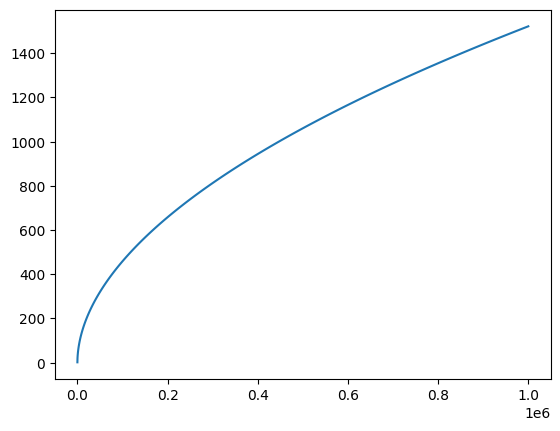

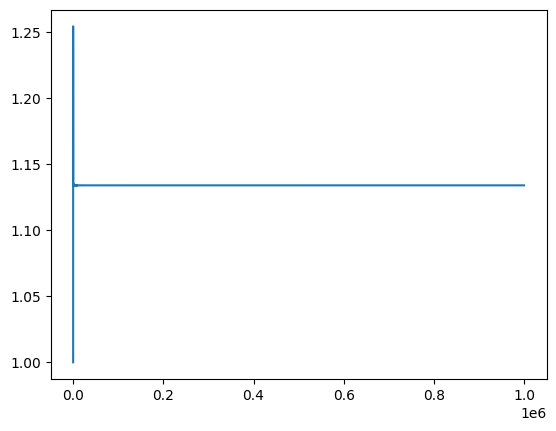

In [6]:
N = 1000000
u = 0.5
v = 0.4

yns = compute_yn(N, u, v)
alpha = solve_for_alpha(u, v, initial_guess=1.0)
print(f"Computed alpha: {alpha}") 

plt.plot(np.arange(1, N+1), yns[1:], label='Y_n')
plt.show()

plt.plot(np.arange(1, N+1), yns[1:] / np.arange(1, N+1)**alpha, label='Y_n')
plt.show()

/tmp/ipykernel_8701/1485251285.py:9: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  alpha_solution = fsolve(equation, initial_guess, xtol=1e-10)[0]


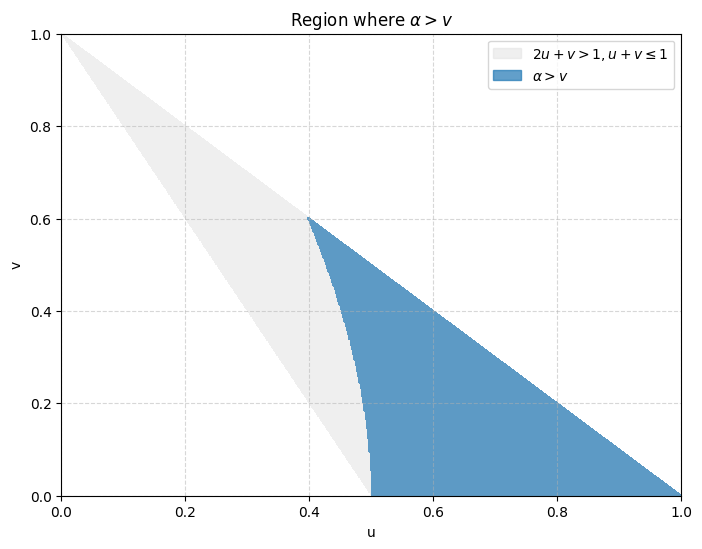

In [5]:
# 1. Redefine grid bounds to match the new constraint [0, 1]
u_vals = np.linspace(0, 1, 500)
v_vals = np.linspace(0, 1, 500)
U, V = np.meshgrid(u_vals, v_vals)

# 2. Apply both constraints: 2u + v > 1 AND u + v <= 1
alpha_grid = np.full_like(U, np.nan)
domain_mask = ((2 * U + V) > 1) & ((U + V) <= 1)

# 3. Solve over the restricted grid
for i in range(U.shape[0]):
    for j in range(U.shape[1]):
        if domain_mask[i, j]:
            alpha_grid[i, j] = solve_for_alpha(U[i, j], V[i, j], initial_guess=V[i, j])

# 4. Identify target region
target_mask = alpha_grid > V

# 5. Visualization
plt.figure(figsize=(8, 6))

# Plot the restricted domain
plt.contourf(U, V, domain_mask, levels=[0.5, 1.5], colors=['#e0e0e0'], alpha=0.5)

# Plot the target region
plt.contourf(U, V, target_mask, levels=[0.5, 1.5], colors=['#1f77b4'], alpha=0.7)

import matplotlib.patches as mpatches
domain_patch = mpatches.Patch(color='#e0e0e0', alpha=0.5, label=r'$2u+v > 1,  u+v \leq 1$')
target_patch = mpatches.Patch(color='#1f77b4', alpha=0.7, label=r'$\alpha > v$')

plt.xlabel('u')
plt.ylabel('v')
plt.title(r'Region where $\alpha > v$')
plt.legend(handles=[domain_patch, target_patch], loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim([0, 1])
plt.ylim([0, 1])

plt.show()